In [29]:
# Fist we are just loading the important libraries for our data analysis and visualization. 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
# Now we will lode the datset
df = pd.read_csv('Dataset  (1).csv')

In [31]:
#  we are simply checking the dataset like what kind of columns and other details it have 
df.sample(5)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
2432,800483,Dastarkhwan,1,Lucknow,"U. P. Press Club, China Bazaar Gate Road, Hazr...",Hazratganj,"Hazratganj, Lucknow",80.936889,26.852639,Mughlai,...,Indian Rupees(Rs.),No,No,No,No,2,4.4,Green,Very Good,818
4333,18387753,Riviera,1,New Delhi,"Ameya Suites, Plot-6, FC-33, Jasola Institutio...",Jasola,"Jasola, New Delhi",77.293532,28.540450,"Continental, North Indian, Chinese, Mughlai, A...",...,Indian Rupees(Rs.),Yes,No,No,No,3,3.2,Orange,Average,8
4761,301204,Mother Sweets,1,New Delhi,"H-9, Vijay Chowk, Krishna Nagar, New Delhi",Krishna Nagar,"Krishna Nagar, New Delhi",77.284378,28.657922,Mithai,...,Indian Rupees(Rs.),No,No,No,No,1,3.4,Orange,Average,15
1247,306134,The Wine Company,1,Gurgaon,"Cyber Hub, DLF Cyber City, Gurgaon","Cyber Hub, DLF Cyber City","Cyber Hub, DLF Cyber City, Gurgaon",77.089048,28.496229,"Italian, European",...,Indian Rupees(Rs.),Yes,No,No,No,4,2.4,Red,Poor,2412
4507,7667,Shake Square,1,New Delhi,"12-UB, Bungalow Road Market, Kamla Nagar, New ...",Kamla Nagar,"Kamla Nagar, New Delhi",77.207416,28.681495,"Beverages, Fast Food",...,Indian Rupees(Rs.),No,No,No,No,1,3.6,Yellow,Good,261


In [43]:
# Now we will checking is there any null values in our dataset
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [33]:
# Now we will check is there any duplicate values in our dataset
df.duplicated().sum()

np.int64(0)

#### Task 1:-  Top Cuisines


- we need to Determine the top three most common cuisines in the dataset.

Top 3 Most Common Cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


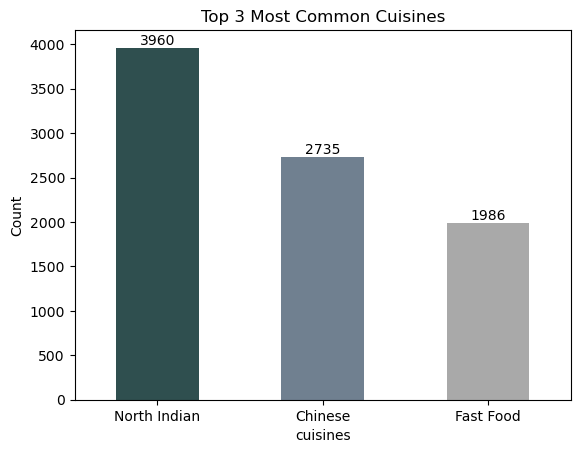

In [34]:

cuisines = df['Cuisines'].str.split(', ')#Here we are Separating the values wherever there is a comma using string split method 
all_cuisines = cuisines.explode() # here we are breaking down the list of cuisines into individual rows

top_cuisines = all_cuisines.value_counts().head(3)# Here we are counting how many times each value appears.

print('='*50)
print("Top 3 Most Common Cuisines:") 
print('='*50)
print(top_cuisines)# Now we are printing each values
print('='*50)


# Now we will see the same Data visually using bar graph for better understanding
plt.Figure(figsize=(10,6))
ax=top_cuisines.plot(kind='bar',color=['darkslategray','slategray','darkgray'])

ax.bar_label(ax.containers[0])

plt.title('Top 3 Most Common Cuisines')
plt.xlabel('cuisines')
plt.ylabel('Count')
plt.xticks(rotation=360)
plt.show()

- Now we need to Calculate the percentage of restaurants that serve each of the top cuisines

Percentage of Restaurants Serving Top Cuisines:
Cuisines
North Indian    41.461627
Chinese         28.635745
Fast Food       20.793634
Name: count, dtype: float64


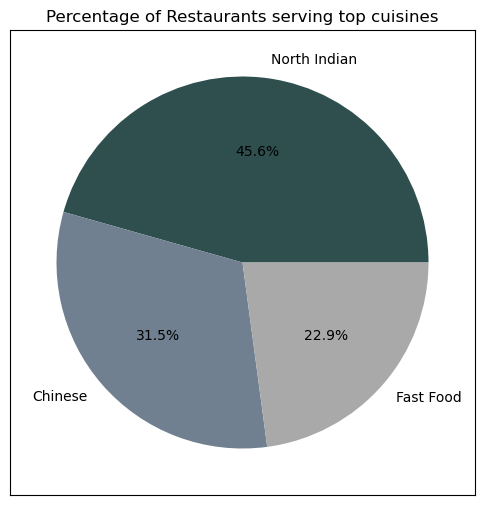

In [35]:

# Percentage calculation
percentage = (top_cuisines / len(df)) * 100
print('='*50)
print("Percentage of Restaurants Serving Top Cuisines:")
print('='*50)
print(percentage)
print('='*50)



# Now we will see the same data visually using pie chart for better understanding
plt.figure(figsize=(6,8))
plt.pie(top_cuisines.values,
        labels=top_cuisines.index,
        autopct='%1.1f%%',
        colors=['darkslategray','slategray','darkgray'])
plt.title('Percentage of Restaurants serving top cuisines')
plt.box(True)
plt.show()

#### Task 2:- City Analysis

- Now we need to identify the city with the highest number of restaurants

In [36]:

top_city = df['City'].value_counts().idxmax()
top_city_count = df['City'].value_counts().max()
print('='*50)
print("City with highest number of restaurants:")
print(top_city, "-", top_city_count)
print('='*50)


City with highest number of restaurants:
New Delhi - 5473


- Now we need to Calculate the average rating for restaurants in each city

In [37]:

city_rating = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)

print('='*50)
print("Average Rating by City:")
print('-'*50)
print(city_rating.head())
print('='*50)


Average Rating by City:
--------------------------------------------------
City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Name: Aggregate rating, dtype: float64


- Now we need to  Determine the city with the highest average rating

In [38]:
print("City with highest average rating")
print('='*50)
print(city_rating.idxmax(), "-", city_rating.max())
print('='*50)

City with highest average rating
Inner City - 4.9


#### Task 3 - Price Range Distribution

- Now we need to create a bar chart to visualize the distribution of price ranges among the restaurants

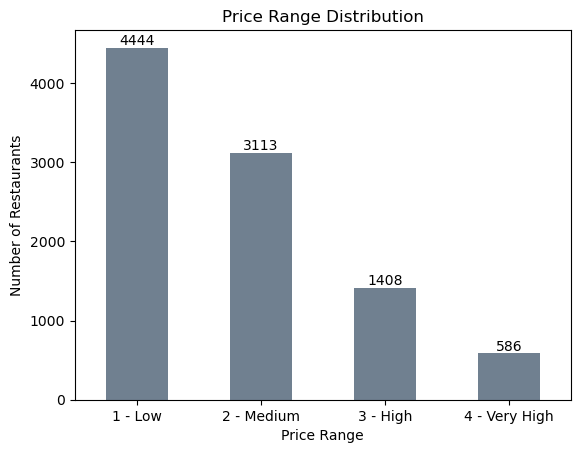

In [39]:
price_counts = df['Price range'].value_counts().sort_index()

price_labels = {1: '1 - Low',2: '2 - Medium',3: '3 - High', 4: '4 - Very High'}

price_counts_labeled = price_counts.rename(index=price_labels)
ax = price_counts_labeled.plot(kind='bar', color=['slategray'])
ax.bar_label(ax.containers[0])

plt.title('Price Range Distribution')
plt.xlabel('Price Range')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=0)
plt.show()

- Calculate the percentage of restaurants in each price range category

In [ ]:
price_percentage =(price_counts / len(df)) * 100 # we are calculating the persantage
print('='*50)
print("Percentage of Restaurants in Each Price Range:")
print('='*50)
print(price_percentage)
print('='*50)


Percentage of Restaurants in Each Price Range:
Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64


#### Task 4 - Online Delivery

- Now we need to Determine the percentage of the restaurants that offer online delivery.

In [41]:
online_delivery = df['Has Online delivery'].value_counts()
percentage_online = (online_delivery / len(df)) * 100
print('='*50)
print("Percentage of Restaurants with Online Delivery:")
print('-'*50)
print(percentage_online)
print('='*50)

Percentage of Restaurants with Online Delivery:
--------------------------------------------------
Has Online delivery
No     74.337766
Yes    25.662234
Name: count, dtype: float64


- now we need to Compare the average ratings of restaurants with and without online delivery

In [42]:
rating_comparison = df.groupby('Has Online delivery')['Aggregate rating'].mean()
print('='*50)
print("Average Ratings Comparison:")
print('-'*50)
print(rating_comparison)
print('='*50)


Average Ratings Comparison:
--------------------------------------------------
Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64
